# Exploratory Data Analysis (EDA)
## Crop Disease Detection Dataset

This notebook analyzes:
- Class distribution across train/val/test splits
- Dataset composition and crop diversity
- Image statistics and metadata

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import logging

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

## 1. Load Dataset Metadata

In [2]:
metadata_path = Path('../dataset/dataset_metadata.json')

with open(metadata_path, 'r') as f:
    metadata = json.load(f)

logger.info(f"Loaded metadata for {metadata['num_classes']} classes")
logger.info(f"Total images: {metadata['total_images']}")

print(f"Classes: {metadata['num_classes']}")
print(f"Total Images: {metadata['total_images']:,}")

INFO:__main__:Loaded metadata for 53 classes
INFO:__main__:Total images: 152127


Classes: 53
Total Images: 152,127


## 2. Build Distribution DataFrame

In [3]:
# Extract distribution data
distribution_data = []

for class_name, splits in metadata['split_counts'].items():
    crop = class_name.split('___')[0]
    disease = class_name.split('___')[1] if len(class_name.split('___')) > 1 else ''
    total = splits['train'] + splits['val'] + splits['test']
    
    distribution_data.append({
        'Class': class_name,
        'Crop': crop,
        'Disease': disease,
        'Train': splits['train'],
        'Val': splits['val'],
        'Test': splits['test'],
        'Total': total,
        'Train%': (splits['train']/total)*100,
        'Val%': (splits['val']/total)*100,
        'Test%': (splits['test']/total)*100
    })

df_dist = pd.DataFrame(distribution_data)
logger.info(f"Created distribution dataframe with shape {df_dist.shape}")
print(f"\nDataset Distribution Summary:")
print(f"Total Train: {df_dist['Train'].sum():,}")
print(f"Total Val: {df_dist['Val'].sum():,}")
print(f"Total Test: {df_dist['Test'].sum():,}")
print(f"\nSplit Ratios:")
print(f"Train: {df_dist['Train'].sum() / df_dist['Total'].sum() * 100:.1f}%")
print(f"Val: {df_dist['Val'].sum() / df_dist['Total'].sum() * 100:.1f}%")
print(f"Test: {df_dist['Test'].sum() / df_dist['Total'].sum() * 100:.1f}%")

INFO:__main__:Created distribution dataframe with shape (53, 10)



Dataset Distribution Summary:
Total Train: 121,207
Total Val: 15,431
Total Test: 15,489

Split Ratios:
Train: 79.7%
Val: 10.1%
Test: 10.2%


In [4]:
df_dist.head(10)

,Class,Crop,Disease,Train,Val,Test,Total,Train%,Val%,Test%
0,Apple___Black_Rot,Apple,Black_Rot,1987,248,249,2484,79.991948,9.983897,10.024155
1,Apple___Cedar_Apple_Rust,Apple,Cedar_Apple_Rust,1760,220,220,2200,80.000000,10.000000,10.000000
2,Apple___Healthy,Apple,Healthy,2008,251,251,2510,80.000000,10.000000,10.000000
3,Apple___Scab,Apple,Scab,2016,252,252,2520,80.000000,10.000000,10.000000
4,Cashew___Anthracnose,Cashew,Anthracnose,3201,399,400,4000,80.025000,9.975000,10.000000
5,Cashew___Gumosis,Cashew,Gumosis,2024,253,254,2531,79.968392,9.996049,10.035559
6,Cashew___Healthy,Cashew,Healthy,3201,399,400,4000,80.025000,9.975000,10.000000
7,Cashew___Leaf_Miner,Cashew,Leaf_Miner,3201,399,400,4000,80.025000,9.975000,10.000000
8,Cashew___Red_Rust,Cashew,Red_Rust,3201,399,400,4000,80.025000,9.975000,10.000000
9,Cassava___Bacterial_Blight,Cassava,Bacterial_Blight,2699,650,651,4000,67.475000,16.250000,16.275000


## 3. Class Balance Analysis

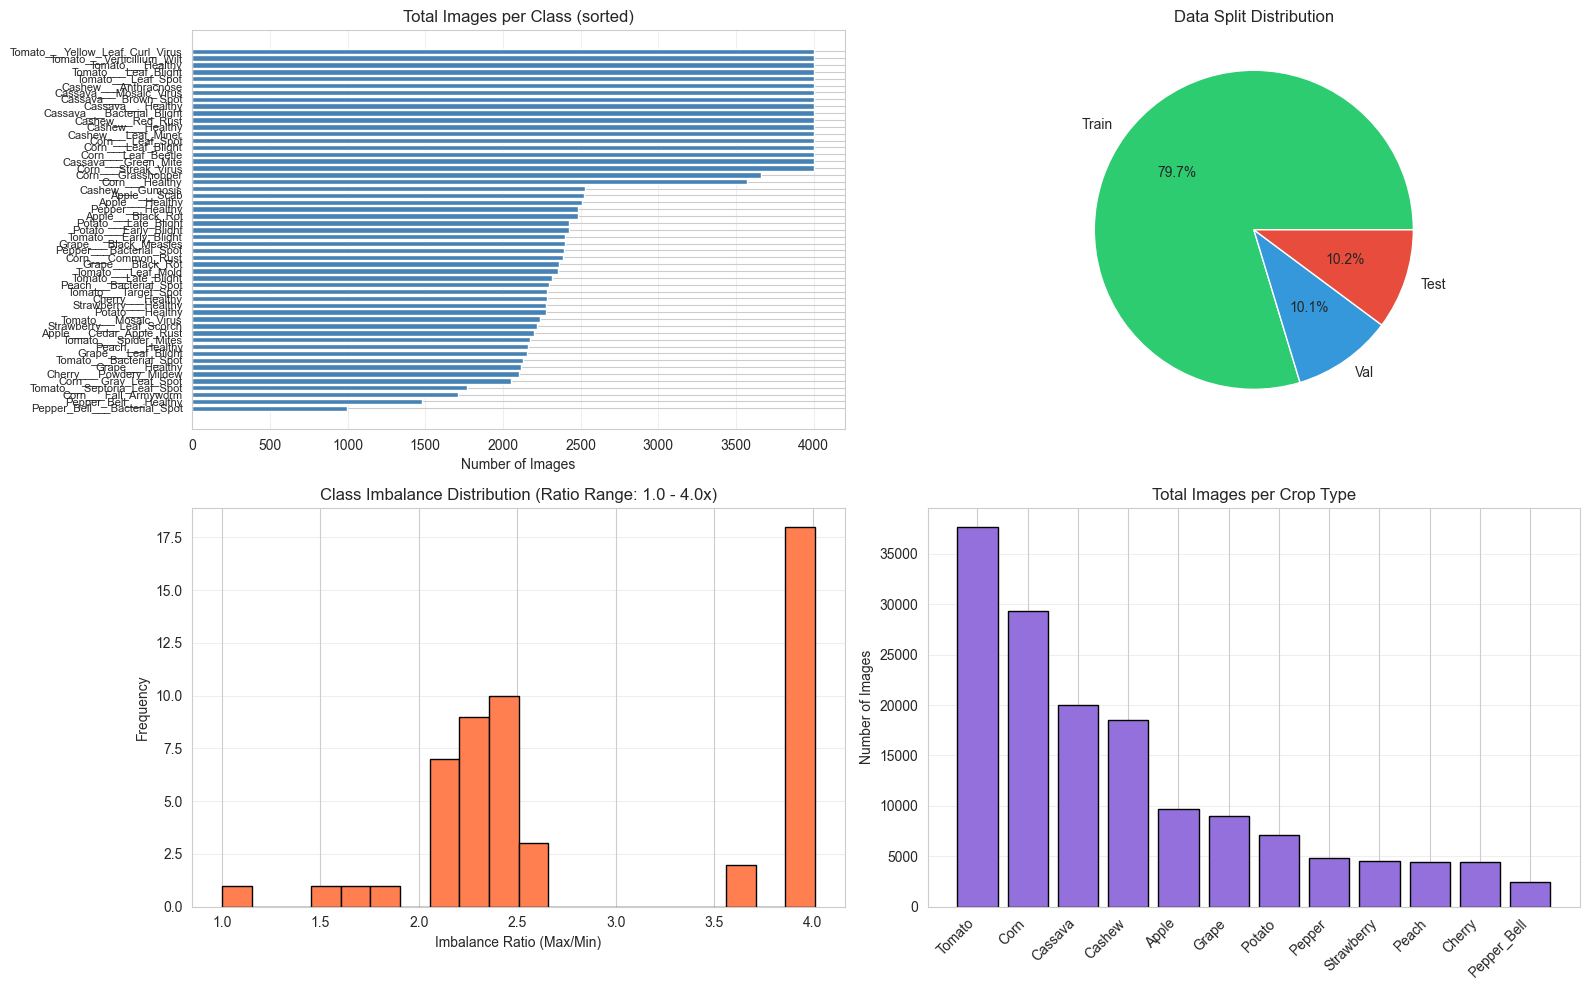

INFO:__main__:Saved class distribution plot


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Total samples per class
ax = axes[0, 0]
df_sorted = df_dist.sort_values('Total', ascending=True)
ax.barh(range(len(df_sorted)), df_sorted['Total'], color='steelblue')
ax.set_yticks(range(len(df_sorted)))
ax.set_yticklabels(df_sorted['Class'], fontsize=8)
ax.set_xlabel('Number of Images')
ax.set_title('Total Images per Class (sorted)')
ax.grid(axis='x', alpha=0.3)

# Split distribution pie
ax = axes[0, 1]
split_totals = [df_dist['Train'].sum(), df_dist['Val'].sum(), df_dist['Test'].sum()]
ax.pie(split_totals, labels=['Train', 'Val', 'Test'], autopct='%1.1f%%', 
       colors=['#2ecc71', '#3498db', '#e74c3c'])
ax.set_title('Data Split Distribution')

# Class imbalance ratio
ax = axes[1, 0]
max_class = df_dist['Total'].max()
min_class = df_dist['Total'].min()
imbalance_ratio = df_dist['Total'] / df_dist['Total'].min()
ax.hist(imbalance_ratio, bins=20, color='coral', edgecolor='black')
ax.set_xlabel('Imbalance Ratio (Max/Min)')
ax.set_ylabel('Frequency')
ax.set_title(f'Class Imbalance Distribution (Ratio Range: 1.0 - {imbalance_ratio.max():.1f}x)')
ax.grid(axis='y', alpha=0.3)

# Crop-wise distribution
ax = axes[1, 1]
crop_totals = df_dist.groupby('Crop')['Total'].sum().sort_values(ascending=False)
ax.bar(range(len(crop_totals)), crop_totals.values, color='mediumpurple', edgecolor='black')
ax.set_xticks(range(len(crop_totals)))
ax.set_xticklabels(crop_totals.index, rotation=45, ha='right')
ax.set_ylabel('Number of Images')
ax.set_title('Total Images per Crop Type')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../notebooks/figures/01_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

logger.info('Saved class distribution plot')

## 4. Statistical Summary

In [6]:
print("\n=== CLASS IMBALANCE STATISTICS ===")
print(f"Min samples per class: {df_dist['Total'].min()}")
print(f"Max samples per class: {df_dist['Total'].max()}")
print(f"Mean samples per class: {df_dist['Total'].mean():.1f}")
print(f"Median samples per class: {df_dist['Total'].median():.1f}")
print(f"Std Dev: {df_dist['Total'].std():.1f}")
print(f"Imbalance Ratio (Max/Min): {df_dist['Total'].max() / df_dist['Total'].min():.2f}x")

print("\n=== TOP 5 LARGEST CLASSES ===")
print(df_dist.nlargest(5, 'Total')[['Class', 'Total']])

print("\n=== TOP 5 SMALLEST CLASSES ===")
print(df_dist.nsmallest(5, 'Total')[['Class', 'Total']])

print("\n=== CROP TYPE COVERAGE ===")
crop_stats = df_dist.groupby('Crop').agg({
    'Total': ['count', 'sum', 'min', 'max'],
    'Class': 'count'
}).round(0)
crop_stats.columns = ['Num_Classes', 'Total_Images', 'Min_Class', 'Max_Class', 'Class_Count']
print(crop_stats.sort_values('Total_Images', ascending=False))


=== CLASS IMBALANCE STATISTICS ===
Min samples per class: 997
Max samples per class: 4000
Mean samples per class: 2870.3
Median samples per class: 2424.0
Std Dev: 896.3
Imbalance Ratio (Max/Min): 4.01x

=== TOP 5 LARGEST CLASSES ===
                        Class  Total
4        Cashew___Anthracnose   4000
6            Cashew___Healthy   4000
7         Cashew___Leaf_Miner   4000
8           Cashew___Red_Rust   4000
9  Cassava___Bacterial_Blight   4000

=== TOP 5 SMALLEST CLASSES ===
                           Class  Total
33  Pepper_Bell___Bacterial_Spot    997
34         Pepper_Bell___Healthy   1478
17          Corn___Fall_Armyworm   1709
48   Tomato___Septoria_Leaf_Spot   1771
19         Corn___Gray_Leaf_Spot   2049

=== CROP TYPE COVERAGE ===
             Num_Classes  Total_Images  Min_Class  Max_Class  Class_Count
Crop                                                                     
Tomato                13         37665       1771       4000           13
Corn                  

## 5. Healthy vs Disease Distribution

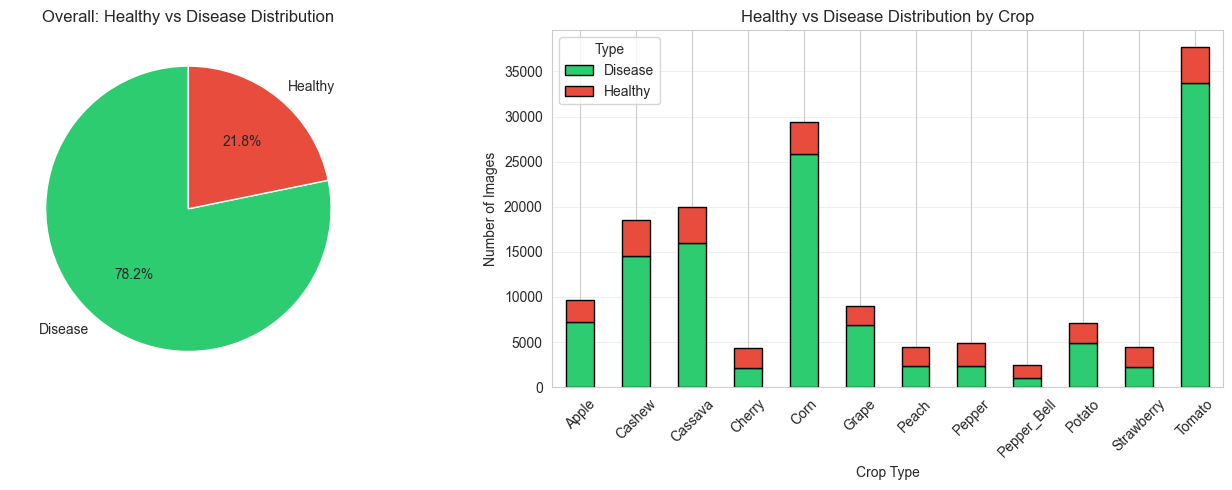

In [7]:
df_dist['Type'] = df_dist['Disease'].apply(lambda x: 'Healthy' if x == 'Healthy' else 'Disease')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall healthy vs disease
ax = axes[0]
type_counts = df_dist.groupby('Type')['Total'].sum()
colors_type = ['#2ecc71', '#e74c3c']
ax.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%', colors=colors_type, startangle=90)
ax.set_title('Overall: Healthy vs Disease Distribution')

# By crop
ax = axes[1]
crop_type_dist = df_dist.groupby(['Crop', 'Type'])['Total'].sum().unstack(fill_value=0)
crop_type_dist.plot(kind='bar', stacked=True, ax=ax, color=colors_type, edgecolor='black')
ax.set_xlabel('Crop Type')
ax.set_ylabel('Number of Images')
ax.set_title('Healthy vs Disease Distribution by Crop')
ax.legend(title='Type')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../notebooks/figures/02_healthy_vs_disease.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Data Completeness Check

In [8]:
print("\n=== DATA COMPLETENESS ===")
print(f"Total Classes Expected: {metadata['num_classes']}")
print(f"Classes with Data: {len(df_dist)}")
print(f"Classes Covered: {len(df_dist)/metadata['num_classes']*100:.1f}%")

# Check split consistency
print("\n=== SPLIT CONSISTENCY ===")
for class_name in df_dist['Class'].head(5):
    row = df_dist[df_dist['Class'] == class_name].iloc[0]
    print(f"{class_name}: Train={int(row['Train'])}, Val={int(row['Val'])}, Test={int(row['Test'])}, "
          f"Ratio={row['Train%']:.1f}%/{row['Val%']:.1f}%/{row['Test%']:.1f}%")


=== DATA COMPLETENESS ===
Total Classes Expected: 53
Classes with Data: 53
Classes Covered: 100.0%

=== SPLIT CONSISTENCY ===
Apple___Black_Rot: Train=1987, Val=248, Test=249, Ratio=80.0%/10.0%/10.0%
Apple___Cedar_Apple_Rust: Train=1760, Val=220, Test=220, Ratio=80.0%/10.0%/10.0%
Apple___Healthy: Train=2008, Val=251, Test=251, Ratio=80.0%/10.0%/10.0%
Apple___Scab: Train=2016, Val=252, Test=252, Ratio=80.0%/10.0%/10.0%
Cashew___Anthracnose: Train=3201, Val=399, Test=400, Ratio=80.0%/10.0%/10.0%
